# HW03 Problem 3 — FashionMNIST Image Classifier with PyTorch

**Author:** Paul Schwartzberg

**Course:** CSCI E-89 Deep Learning — Assignment 03, Problem 3

**File:** `e89_Schwartzberg_Paul_HW03_Prob3.ipynb`

## About this notebook

This notebook was produced in a **single, longer prompt** to Claude Code, in a
brand-new session, asking it to accomplish in one pass what Problems 1 and 2
of this assignment did incrementally:

1. Build a FashionMNIST image classifier in PyTorch, following the section
   titled **"Building an Image Classifier with PyTorch"** in the course's
   reference notebook `10_neural_nets_with_pytorch.ipynb` (Chapter 10 of
   *Hands-On Machine Learning with Scikit-Learn and PyTorch*, Aurélien Géron,
   2025). That means the same dataset (FashionMNIST via TorchVision), the
   same MLP architecture (`Flatten → Linear(784, 300) → ReLU →
   Linear(300, 100) → ReLU → Linear(100, 10)`), the same loss
   (`CrossEntropyLoss`), optimizer (`SGD`, `lr=0.1`), batch size (32),
   train/valid split (55,000 / 5,000), and training loop (20 epochs, tracked
   with `torchmetrics.Accuracy`).
2. **Add one thing that reference section does not already do on its own:**
   plot training accuracy across epochs (validation accuracy is plotted
   alongside it as a bonus).
3. Wrap the whole thing into one runnable, top-to-bottom tested Jupyter
   notebook, with every cell (or group of cells) labeled with a markdown
   heading and/or comment describing what it does.

The notebook trains on CPU only (no GPU is available in this environment),
which is expected to take a few minutes for 20 epochs.


## 1. Setup and Imports

Import PyTorch, TorchVision (for the FashionMNIST dataset and image transforms), TorchMetrics (for tracking accuracy during training), and Matplotlib/NumPy for plotting.

In [1]:
# Cell: imports needed for the whole notebook (data loading, model, training,
# metrics, and plotting).
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms.v2 as T

import torchmetrics

# Make the plots a bit more legible.
plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=14)
plt.rc('legend', fontsize=11)

print("PyTorch version:", torch.__version__)
print("TorchVision version:", torchvision.__version__)
print("TorchMetrics version:", torchmetrics.__version__)


PyTorch version: 2.14.0+cu130
TorchVision version: 0.29.0+cu130
TorchMetrics version: 1.9.0


## 2. Select the Compute Device

Use a GPU if one is available (CUDA or Apple's MPS backend), otherwise fall back to the CPU. This container has no GPU, so training below runs on CPU.

In [2]:
# Cell: pick the fastest available device — CUDA GPU, Apple MPS, or CPU.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Using device:", device)


Using device: cpu


## 3. Load the FashionMNIST Dataset (TorchVision)

Download FashionMNIST via `torchvision.datasets.FashionMNIST` (60,000 training images + 10,000 test images, 28x28 grayscale). Convert images to float32 tensors scaled to `[0, 1]`, then split the 60,000 training images into 55,000 for training and 5,000 for validation, exactly as the reference notebook does (with a fixed random seed for reproducibility).

In [3]:
# Cell: download FashionMNIST and build the transform pipeline.
# ToImage() turns the PIL image into a tensor; ToDtype(..., scale=True)
# converts it to float32 and rescales pixel values from [0, 255] to [0, 1].
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

# Cell (continued): split the 60,000 training images into a training set
# (55,000) and a validation set (5,000), with a fixed seed so the split is
# reproducible.
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

print(f"Training samples:   {len(train_data)}")
print(f"Validation samples: {len(valid_data)}")
print(f"Test samples:       {len(test_data)}")
print(f"Classes: {train_and_valid_data.classes}")


Training samples:   55000
Validation samples: 5000
Test samples:       10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 4. Inspect a Sample Image

Sanity-check the data: each dataset entry is an `(image, target)` tuple. FashionMNIST images are grayscale (1 channel) and 28x28 pixels.

In [4]:
# Cell: look at the very first training sample - its tensor shape, dtype,
# and the human-readable class name of its label.
X_sample, y_sample = train_data[0]

print("Image shape (channels, rows, cols):", X_sample.shape)
print("Image dtype:", X_sample.dtype)
print("Label index:", y_sample)
print("Label class name:", train_and_valid_data.classes[y_sample])


Image shape (channels, rows, cols): torch.Size([1, 28, 28])
Image dtype: torch.float32
Label index: 9
Label class name: Ankle boot


## 5. Create DataLoaders

Wrap the train/validation/test datasets in `DataLoader`s with a batch size of 32, shuffling only the training data each epoch.

In [5]:
# Cell: build the mini-batch DataLoaders used during training and
# evaluation.
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches:       {len(test_loader)}")


Training batches:   1719
Validation batches: 157
Test batches:       313


## 6. Define the Image Classifier Model

A simple multilayer perceptron (MLP): flatten the 28x28 image into a 784-length vector, then two hidden layers (300 and 100 units, ReLU activations), followed by an output layer with 10 logits (one per clothing class). This is the exact architecture used in the reference notebook's image classifier.

In [6]:
# Cell: the ImageClassifier model - a Flatten layer followed by an MLP.
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

# Cell (continued): instantiate the model and move it to the chosen device.
# 1 * 28 * 28 = 784 input pixels, 10 output classes.
torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                         n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

print(model)


ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)


## 7. Evaluation Helper and Training Loop (TorchMetrics-based)

Two helper functions, matching the reference notebook's TorchMetrics-based training utilities:

- `evaluate_tm` runs the model over a data loader in eval mode and computes an aggregate metric (e.g. accuracy) with `torchmetrics`.
- `train2` runs the full training loop for `n_epochs`, tracking the mean training loss, training accuracy, and validation accuracy for every epoch in a `history` dictionary (this history is what we use below to plot training accuracy).

In [7]:
# Cell: evaluate_tm - run a model over a data loader and compute a
# torchmetrics metric (used for validation accuracy during training).
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()


# Cell (continued): train2 - the main training loop. For each epoch it
# iterates over the training batches (forward pass, loss, backward pass,
# optimizer step), tracks the running training loss and training accuracy,
# then evaluates validation accuracy at the end of the epoch. Everything is
# recorded in `history` so it can be plotted afterwards.
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


## 8. Train the Classifier

Train for 20 epochs with plain SGD (`lr=0.1`) and multiclass accuracy (`torchmetrics.Accuracy`) as the tracked metric — the same hyperparameters used in the reference notebook. On this CPU-only container this takes a few minutes.

In [8]:
# Cell: train the ImageClassifier for 20 epochs, keeping the returned
# history (train loss / train accuracy / valid accuracy per epoch) for the
# accuracy plot in the next section.
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs = 20

history = train2(model, optimizer, xentropy, accuracy, train_loader,
                  valid_loader, n_epochs)


Epoch 1/20, train loss: 0.6060, train metric: 0.7814, valid metric: 0.8424


Epoch 2/20, train loss: 0.4061, train metric: 0.8496, valid metric: 0.8402


Epoch 3/20, train loss: 0.3630, train metric: 0.8661, valid metric: 0.8494


Epoch 4/20, train loss: 0.3355, train metric: 0.8768, valid metric: 0.8638


Epoch 5/20, train loss: 0.3154, train metric: 0.8829, valid metric: 0.8782


...

Epoch 16/20, train loss: 0.2078, train metric: 0.9196, valid metric: 0.8886


Epoch 17/20, train loss: 0.2033, train metric: 0.9233, valid metric: 0.8870


Epoch 18/20, train loss: 0.1991, train metric: 0.9230, valid metric: 0.8846


Epoch 19/20, train loss: 0.1916, train metric: 0.9266, valid metric: 0.8812


Epoch 20/20, train loss: 0.1876, train metric: 0.9286, valid metric: 0.8788


## 9. Plot Training and Validation Accuracy Across Epochs

**This is the addition beyond the reference notebook's image-classifier section** (per the assignment: *"Add code that will plot the training accuracy"*). The reference section trains the classifier and reports per-epoch metrics as printed text only — it never plots them. Here we plot both training accuracy and validation accuracy (a nice-to-have) against epoch number, using the `history` dictionary returned by `train2` above.

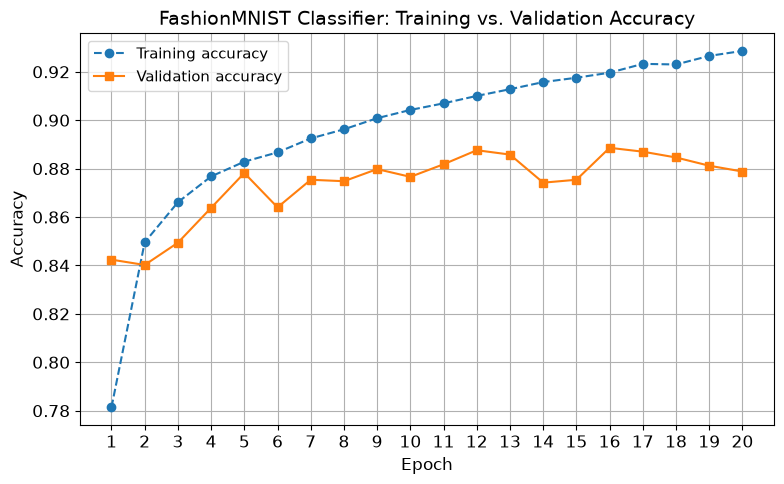

Final training accuracy:   0.9286
Final validation accuracy: 0.8788


In [9]:
# Cell: plot training accuracy (and validation accuracy) vs. epoch number.
# This is the extra piece the reference notebook's image-classifier section
# does not include on its own.
epochs = np.arange(1, n_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_metrics"], "o--", label="Training accuracy")
plt.plot(epochs, history["valid_metrics"], "s-", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FashionMNIST Classifier: Training vs. Validation Accuracy")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("training_accuracy_prob3.png", dpi=150)
plt.show()

print(f"Final training accuracy:   {history['train_metrics'][-1]:.4f}")
print(f"Final validation accuracy: {history['valid_metrics'][-1]:.4f}")


## 10. Make Predictions on Sample Images

Switch the model to evaluation mode and run it on a batch of unseen **test** images (held out from training and validation entirely). For the first 3 samples, show the predicted class, the actual class, and the model's softmax class probabilities — the same inspection the reference notebook performs.

In [10]:
# Cell: run the trained model on a batch of test images and get the
# predicted class (index of the largest logit) for the first 3 samples.
model.eval()
X_new, y_new = next(iter(test_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit
print("Predicted class indices:", y_pred)


Predicted class indices: tensor([9, 2, 1])


In [11]:
# Cell: translate predicted class indices into human-readable class names.
predicted_labels = [train_and_valid_data.classes[index] for index in y_pred]
print("Predicted labels:", predicted_labels)


Predicted labels: ['Ankle boot', 'Pullover', 'Trouser']


In [12]:
# Cell: compare against the true labels for these 3 samples.
actual_labels = [train_and_valid_data.classes[index] for index in y_new[:3]]
print("Actual labels:   ", actual_labels)
print("Correct?         ", [p == a for p, a in zip(predicted_labels, actual_labels)])


Actual labels:    ['Ankle boot', 'Pullover', 'Trouser']
Correct?          [True, True, True]


In [13]:
# Cell: the model's full softmax probability distribution over the 10
# classes for each of the 3 samples (rounded for readability).
y_proba = F.softmax(y_pred_logits, dim=1)
if device == "mps":
    y_proba = y_proba.cpu()
y_proba.round(decimals=3)


tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         1.0000],
        [0.0000, 0.0000, 0.9970, 0.0000, 0.0020, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])

In [14]:
# Cell: the top-4 most likely classes (and their probabilities) for each
# of the 3 samples.
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1)
if device == "mps":
    y_top4_probas = y_top4_probas.cpu()
print("Top-4 class indices:\n", y_top4_indices)
print("Top-4 class probabilities:\n", y_top4_probas.round(decimals=3))


Top-4 class indices:
 tensor([[9, 7, 5, 1],
        [2, 4, 6, 0],
        [1, 6, 4, 0]])
Top-4 class probabilities:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.9970, 0.0020, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000]])


## 11. Visualize Sample Predictions

A more visual check on real model behavior: plot a grid of test images with the model's predicted label (and the true label) as the title, colored green when correct and red when wrong.

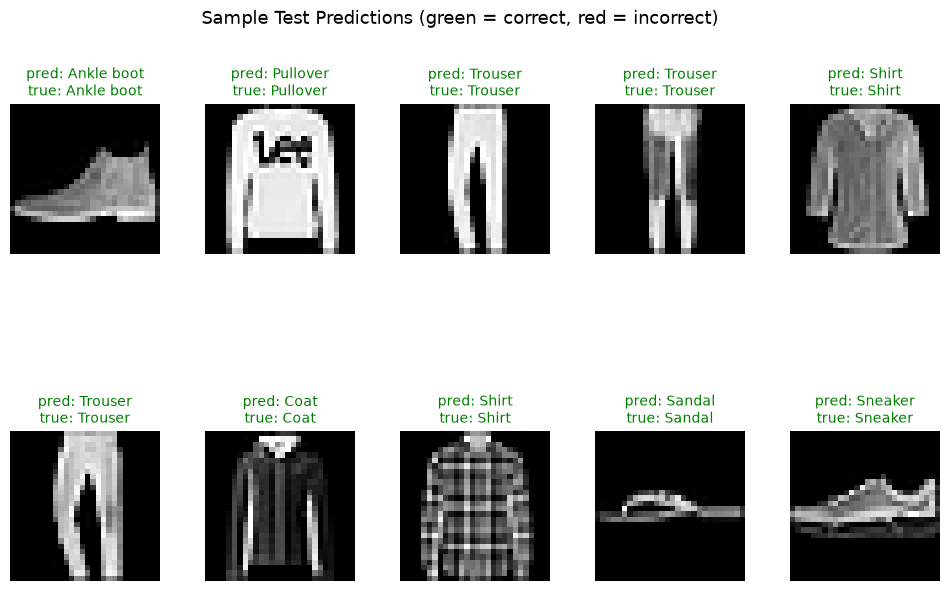

10/10 sample predictions correct.


In [15]:
# Cell: visualize a grid of test images together with the model's
# predictions vs. the ground-truth labels.
model.eval()
X_vis, y_vis = next(iter(test_loader))
n_vis = 10
X_vis_dev = X_vis[:n_vis].to(device)
with torch.no_grad():
    vis_logits = model(X_vis_dev)
vis_pred = vis_logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 7))
for i, ax in enumerate(axes.flat):
    img = X_vis[i, 0]  # drop the channel dimension for grayscale display
    true_idx = y_vis[i].item()
    pred_idx = vis_pred[i].item()
    true_name = train_and_valid_data.classes[true_idx]
    pred_name = train_and_valid_data.classes[pred_idx]
    correct = pred_idx == true_idx

    ax.imshow(img, cmap="gray")
    ax.set_title(f"pred: {pred_name}\ntrue: {true_name}",
                 color=("green" if correct else "red"), fontsize=10)
    ax.axis("off")

fig.suptitle("Sample Test Predictions (green = correct, red = incorrect)",
             fontsize=13)
fig.subplots_adjust(hspace=0.45, wspace=0.3, top=0.90)
plt.savefig("sample_predictions_prob3.png", dpi=150)
plt.show()

n_correct = sum(p == t.item() for p, t in zip(vis_pred.tolist(), y_vis[:n_vis]))
print(f"{n_correct}/{n_vis} sample predictions correct.")


## 12. Model Size

For reference, the total number of trainable parameters in the model.

In [16]:
# Cell: total number of trainable parameters in the model.
n_params = sum(param.numel() for param in model.parameters())
print(f"Total trainable parameters: {n_params:,}")


Total trainable parameters: 266,610


## 13. Summary

Final numbers from this run, computed directly from the training `history` (not hand-typed), so they reflect exactly what happened above.

In [17]:
# Cell: print a final summary of the training run.
print("=" * 60)
print("FashionMNIST Image Classifier — Summary")
print("=" * 60)
print(f"Epochs trained:              {n_epochs}")
print(f"Final training loss:         {history['train_losses'][-1]:.4f}")
print(f"Final training accuracy:     {history['train_metrics'][-1]:.4f}")
print(f"Final validation accuracy:   {history['valid_metrics'][-1]:.4f}")
print(f"Best validation accuracy:    {max(history['valid_metrics']):.4f} "
      f"(epoch {np.argmax(history['valid_metrics']) + 1})")
print(f"Total trainable parameters:  {n_params:,}")
print("=" * 60)


FashionMNIST Image Classifier — Summary
Epochs trained:              20
Final training loss:         0.1876
Final training accuracy:     0.9286
Final validation accuracy:   0.8788
Best validation accuracy:    0.8886 (epoch 16)
Total trainable parameters:  266,610
